In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/d4rklucif3r/social-network-ads/Social_Network_Ads.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
df=pd.read_csv("/kaggle/input/datasets/d4rklucif3r/social-network-ads/Social_Network_Ads.csv")

In [4]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
df.tail()

,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [7]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [8]:
df.columns

Index(['Age', 'EstimatedSalary', 'Purchased'], dtype='object')

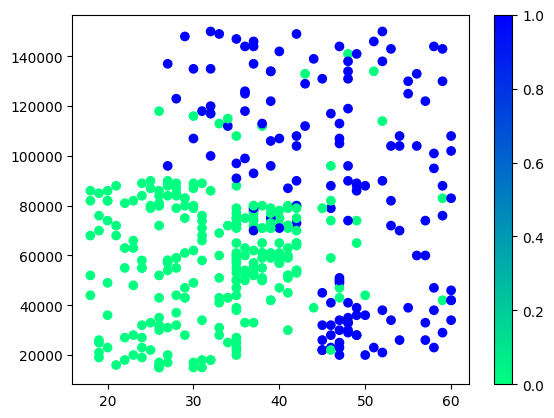

In [9]:
plt.scatter(df["Age"],df["EstimatedSalary"],c=df["Purchased"],cmap="winter_r")
plt.colorbar()


(array([19.,  9., 15., 22., 25., 21., 20., 15., 44., 33., 46., 19.,  9.,
        26., 24.,  7., 11.,  7.,  8., 20.]),
 array([18. , 20.1, 22.2, 24.3, 26.4, 28.5, 30.6, 32.7, 34.8, 36.9, 39. ,
        41.1, 43.2, 45.3, 47.4, 49.5, 51.6, 53.7, 55.8, 57.9, 60. ]),
 <BarContainer object of 20 artists>)

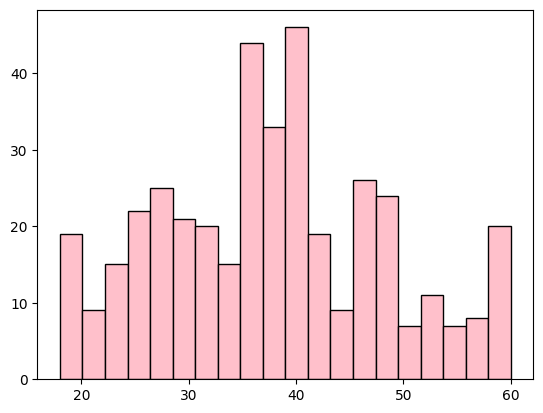

In [10]:
plt.hist(df["Age"],bins=20,edgecolor="black",color="pink")

(array([22., 29., 25., 14., 25., 33., 34., 16., 45., 37., 32.,  8.,  9.,
        13.,  9., 10.,  5., 12., 10., 12.]),
 array([ 15000.,  21750.,  28500.,  35250.,  42000.,  48750.,  55500.,
         62250.,  69000.,  75750.,  82500.,  89250.,  96000., 102750.,
        109500., 116250., 123000., 129750., 136500., 143250., 150000.]),
 <BarContainer object of 20 artists>)

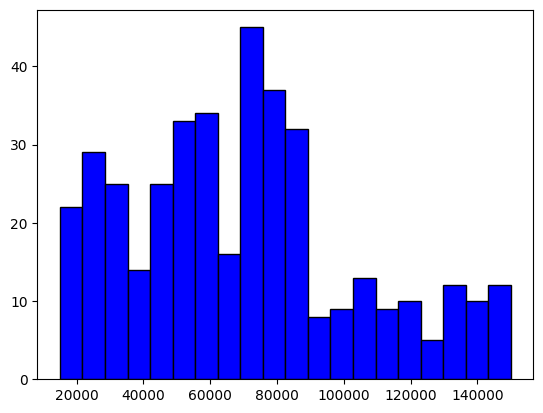

In [11]:
plt.hist(df["EstimatedSalary"],bins=20,edgecolor="black",color="blue")

In [12]:
from sklearn.model_selection import train_test_split
x=df[["Age","EstimatedSalary"]]
y=df["Purchased"]
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)



In [14]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)


LogisticRegression()

In [15]:
Y_pred=model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score,confusion_matrix
print("Accuracy : ",accuracy_score(Y_test,Y_pred))
print(confusion_matrix(Y_test,Y_pred))

Accuracy :  0.8625
[[50  2]
 [ 9 19]]


In [17]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80

